# QAR Baseline vs OpenAP/BADA Fuel-Optimal Trajectories

This notebook uses the A320 QAR trajectory from the OpenAP examples as a baseline, assumes the same flight distance on an eastbound synthetic route from `(0, 0)`, and generates fuel-optimal trajectories with the OpenAP, BADA 3, and BADA 4 performance models.

In [1]:
# ruff: noqa: E402
import os
import sys
import warnings
from pathlib import Path


def find_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for path in (cwd, *cwd.parents):
        if (path / "opentop").is_dir() and (path / "examples").is_dir():
            return path
    raise RuntimeError("Run this notebook from the opentop repository.")


ROOT = find_repo_root()
OPENAP_ROOT = ROOT.parent / "openap"
if OPENAP_ROOT.exists() and str(OPENAP_ROOT) not in sys.path:
    sys.path.insert(0, str(OPENAP_ROOT))

import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import openap
from openap.aero import ft, kts

import opentop as top
import pandas as pd

QAR_FILE = OPENAP_ROOT / "examples" / "data" / "flight_a320_qar.csv"
DEBUG_DIR = ROOT / "debug" / "qar_baseline_comparison"
FIGURE_PATH = DEBUG_DIR / "optimization_vs_qar_distance.png"
BADA3_PATH = os.environ.get("OPENTOP_BADA3_PATH")
BADA4_PATH = os.environ.get("OPENTOP_BADA4_PATH")

DEBUG_DIR.mkdir(parents=True, exist_ok=True)
warnings.filterwarnings("ignore", message="Warning: Wave drag is experimental")

DEBUG_DIR.relative_to(ROOT)

PosixPath('debug/qar_baseline_comparison')

## Load The QAR Baseline

The recorded fuel-flow column is per engine in the QAR file, so this comparison uses the mass delta as the QAR fuel-consumption reference.

In [2]:
def load_qar() -> pd.DataFrame:
    if not QAR_FILE.exists():
        raise FileNotFoundError(f"QAR file not found: {QAR_FILE}")

    raw = pd.read_csv(QAR_FILE)
    df = raw.query("ALTI_STD_FT > 500").copy()
    df["ts"] = df.FLIGHT_TIME - df.FLIGHT_TIME.iloc[0]
    df["dt"] = df.TIME_LAST_PLOT
    df["altitude"] = df.ALTI_STD_FT
    df["tas"] = df.TRUE_AIR_SPD_KT
    df["vertical_rate"] = df.VERT_SPD_FTMN
    df["mass"] = df.MASS_KG
    df["recorded_fuelflow_one_engine_kg_s"] = df.FUEL_FLOW_KGH / 3600.0
    df["recorded_fuel_mass_kg"] = df.mass.iloc[0] - df.mass
    df["distance_km"] = (df.GRND_SPD_KT * kts * df.dt).cumsum() / 1000.0
    df["latitude"] = 0.0
    df["longitude"] = df.distance_km / 111.31949079327358
    df["mach"] = openap.aero.tas2mach(
        df.tas.to_numpy() * kts,
        df.altitude.to_numpy() * ft,
    )
    return df


qar = load_qar()
qar.to_csv(DEBUG_DIR / "qar_fixed_trajectory.csv", index=False)

pd.DataFrame(
    [
        {
            "initial_mass_kg": qar.mass.iloc[0],
            "final_mass_kg": qar.mass.iloc[-1],
            "fuel_from_mass_delta_kg": qar.mass.iloc[0] - qar.mass.iloc[-1],
            "duration_s": qar.ts.iloc[-1],
            "distance_km": qar.distance_km.iloc[-1],
            "max_altitude_ft": qar.altitude.max(),
        }
    ]
)

,initial_mass_kg,final_mass_kg,fuel_from_mass_delta_kg,duration_s,distance_km,max_altitude_ft
0,69648.666336,63992.828651,5655.837685,6929.0,1634.261876,33023.546875


## Generate Fuel-Optimal Trajectories

Set `OPENTOP_RUN_MODEL_COMPARISON=1` and provide `OPENTOP_BADA3_PATH` and `OPENTOP_BADA4_PATH` to regenerate and overwrite the optimized trajectory CSVs. Without that flag, this notebook renders from the existing CSVs in `debug/qar_baseline_comparison`.

In [3]:
RUN_OPTIMIZATION = os.environ.get("OPENTOP_RUN_MODEL_COMPARISON") == "1"
MAX_ITER = 3000

CASES = [
    {
        "label": "openap",
        "actype": "A320",
        "engine": "CFM56-5B4/P",
        "performance_model": "openap",
        "bada_path": None,
    },
    {
        "label": "bada3",
        "actype": "A320",
        "engine": None,
        "performance_model": "bada3",
        "bada_path": BADA3_PATH,
    },
    {
        "label": "bada4",
        "actype": "A320-214",
        "engine": None,
        "performance_model": "bada4",
        "bada_path": BADA4_PATH,
    },
]


def synthetic_destination(distance_km: float):
    lon_delta_deg = distance_km / 111.31949079327358
    return (0.0, 0.0), (0.0, lon_delta_deg)


def check_bada_paths() -> None:
    missing = [
        name
        for name, path in {
            "OPENTOP_BADA3_PATH": BADA3_PATH,
            "OPENTOP_BADA4_PATH": BADA4_PATH,
        }.items()
        if not path or not Path(path).exists()
    ]
    if missing:
        raise FileNotFoundError(
            "Set valid BADA data paths before regenerating trajectories: "
            + ", ".join(missing)
        )


def optimize_same_distance(qar: pd.DataFrame):
    check_bada_paths()

    distance_km = float(qar.distance_km.iloc[-1])
    m0 = float(qar.mass.iloc[0] / openap.prop.aircraft("A320")["mtow"])
    origin, destination = synthetic_destination(distance_km)

    results = {}
    rows = []

    for case in CASES:
        print(f"Optimizing {case['label']}...")
        opt = top.CompleteFlight(
            case["actype"],
            origin,
            destination,
            m0=m0,
            engine=case["engine"],
            performance_model=case["performance_model"],
            bada_path=case["bada_path"],
        )
        opt.setup(max_iter=MAX_ITER)
        result = opt.trajectory(
            objective="fuel",
            return_failed=True,
            result_object=True,
            auto_rescale_objective=True,
        )

        df = result.df.copy()
        df["model"] = case["label"]
        df["solver_success"] = result.success
        df["solver_status"] = result.status
        df["distance_km"] = (
            (df.x - df.x.iloc[0]) ** 2 + (df.y - df.y.iloc[0]) ** 2
        ) ** 0.5 / 1000.0
        df["fuel_burn_kg"] = df.mass.iloc[0] - df.mass
        df.to_csv(DEBUG_DIR / f"optimized_{case['label']}.csv", index=False)

        results[case["label"]] = df
        rows.append(
            {
                "trajectory": case["label"],
                "solver_success": bool(result.success),
                "solver_status": result.status,
                "fuel_kg": float(df.mass.iloc[0] - df.mass.iloc[-1]),
                "time_s": float(df.ts.iloc[-1]),
                "max_altitude_ft": float(df.altitude.max()),
                "mean_mach": float(df.mach.mean()),
                "distance_km": float(df.distance_km.iloc[-1]),
                "source": "optimized",
            }
        )

    return results, pd.DataFrame(rows)


def load_optimized_results():
    results = {}
    rows = []
    for case in CASES:
        label = case["label"]
        df = pd.read_csv(DEBUG_DIR / f"optimized_{label}.csv")
        results[label] = df
        rows.append(
            {
                "trajectory": label,
                "solver_success": bool(df.solver_success.iloc[0])
                if "solver_success" in df
                else True,
                "solver_status": str(df.solver_status.iloc[0])
                if "solver_status" in df
                else "",
                "fuel_kg": float(df.mass.iloc[0] - df.mass.iloc[-1]),
                "time_s": float(df.ts.iloc[-1] - df.ts.iloc[0]),
                "max_altitude_ft": float(df.altitude.max()),
                "mean_mach": float(df.mach.mean()),
                "distance_km": float(df.distance_km.iloc[-1] - df.distance_km.iloc[0]),
                "source": "optimized",
            }
        )
    return results, pd.DataFrame(rows)


if RUN_OPTIMIZATION:
    trajectories, optimized_summary = optimize_same_distance(qar)
else:
    trajectories, optimized_summary = load_optimized_results()

optimized_summary

,trajectory,solver_success,solver_status,fuel_kg,time_s,max_altitude_ft,mean_mach,distance_km,source
0,openap,True,Solve_Succeeded,5570.884751,7597.1476,38001.0,0.703031,1632.433172,optimized
1,bada3,False,Maximum_Iterations_Exceeded,5252.070393,8516.3401,33737.0,0.619680,1632.433172,optimized
2,bada4,False,NonIpopt_Exception_Thrown,5111.467821,8332.9232,32965.0,0.633462,1632.433172,optimized


## Summary

In [4]:
colors = {
    "qar_reference": "tab:green",
    "openap": "tab:blue",
    "bada3": "tab:orange",
    "bada4": "tab:red",
}

qar_summary = pd.DataFrame(
    [
        {
            "trajectory": "qar_reference",
            "solver_success": True,
            "solver_status": "assumed_optimal_reference",
            "fuel_kg": float(qar.mass.iloc[0] - qar.mass.iloc[-1]),
            "time_s": float(qar.ts.iloc[-1] - qar.ts.iloc[0]),
            "max_altitude_ft": float(qar.altitude.max()),
            "mean_mach": float(qar.mach.mean()),
            "distance_km": float(qar.distance_km.iloc[-1] - qar.distance_km.iloc[0]),
            "source": "QAR mass delta",
        }
    ]
)

summary = pd.concat([qar_summary, optimized_summary], ignore_index=True)
summary.to_csv(DEBUG_DIR / "qar_vs_optimized_summary.csv", index=False)
summary

,trajectory,solver_success,solver_status,fuel_kg,time_s,max_altitude_ft,mean_mach,distance_km,source
0,qar_reference,True,assumed_optimal_reference,5655.837685,6929.0000,33023.546875,0.734955,1634.174421,QAR mass delta
1,openap,True,Solve_Succeeded,5570.884751,7597.1476,38001.000000,0.703031,1632.433172,optimized
2,bada3,False,Maximum_Iterations_Exceeded,5252.070393,8516.3401,33737.000000,0.619680,1632.433172,optimized
3,bada4,False,NonIpopt_Exception_Thrown,5111.467821,8332.9232,32965.000000,0.633462,1632.433172,optimized


## Profile Comparison

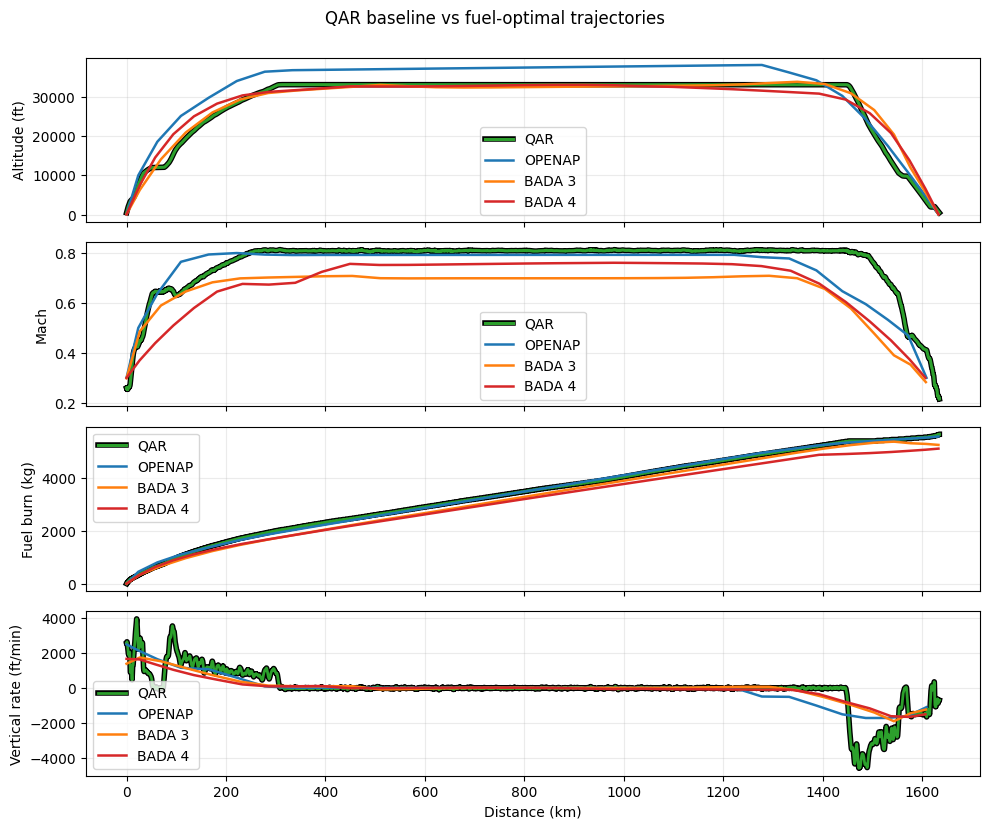

In [5]:
def plot_profiles(save_path: Path | None = None):
    qar_effect = [pe.Stroke(linewidth=4.0, foreground="black"), pe.Normal()]
    fig, axes = plt.subplots(4, 1, figsize=(10, 8.5), sharex=True)

    qar_lines = [
        axes[0].plot(
            qar.distance_km,
            qar.altitude,
            color=colors["qar_reference"],
            lw=2.2,
            label="QAR",
        )[0],
        axes[1].plot(
            qar.distance_km,
            qar.mach,
            color=colors["qar_reference"],
            lw=2.2,
            label="QAR",
        )[0],
        axes[2].plot(
            qar.distance_km,
            qar.mass.iloc[0] - qar.mass,
            color=colors["qar_reference"],
            lw=2.2,
            label="QAR",
        )[0],
        axes[3].plot(
            qar.distance_km,
            qar.vertical_rate,
            color=colors["qar_reference"],
            lw=2.0,
            label="QAR",
        )[0],
    ]
    for line in qar_lines:
        line.set_path_effects(qar_effect)

    for name, df in trajectories.items():
        label = (
            name.upper() if name == "openap" else name.upper().replace("BADA", "BADA ")
        )
        ctrl = df.iloc[:-1]
        axes[0].plot(
            df.distance_km, df.altitude, color=colors[name], lw=1.8, label=label
        )
        axes[1].plot(
            ctrl.distance_km, ctrl.mach, color=colors[name], lw=1.8, label=label
        )
        axes[2].plot(
            df.distance_km,
            df.mass.iloc[0] - df.mass,
            color=colors[name],
            lw=1.8,
            label=label,
        )
        axes[3].plot(
            ctrl.distance_km,
            ctrl.vertical_rate,
            color=colors[name],
            lw=1.8,
            label=label,
        )

    axes[0].set_ylabel("Altitude (ft)")
    axes[1].set_ylabel("Mach")
    axes[2].set_ylabel("Fuel burn (kg)")
    axes[3].set_ylabel("Vertical rate (ft/min)")
    axes[3].set_xlabel("Distance (km)")

    for ax in axes:
        ax.grid(True, alpha=0.25)
        ax.legend(loc="best")

    fig.suptitle("QAR baseline vs fuel-optimal trajectories")
    fig.tight_layout(rect=[0, 0.01, 1, 0.98])
    if save_path is not None:
        fig.savefig(save_path, dpi=180)
    return fig, axes


plot_profiles(FIGURE_PATH);

## BADA 4 Profile Checks

In [6]:
bada4 = trajectories["bada4"]
segment = bada4[(bada4.distance_km >= 950) & (bada4.distance_km <= 1420)]
cruise = bada4[
    (bada4.distance_km >= 500) & (bada4.distance_km <= bada4.distance_km.iloc[-1] - 300)
]

{
    "bada4_segment_mach_min": float(segment.mach.min()),
    "bada4_segment_mach_max": float(segment.mach.max()),
    "bada4_cruise_min_mach": float(cruise.mach.min()),
    "bada4_max_mach_step": float(bada4.mach.diff().abs().dropna().max()),
    "bada4_cruise_vs_below_minus_250_count": int((cruise.vertical_rate < -250).sum()),
}

{'bada4_segment_mach_min': 0.6776,
 'bada4_segment_mach_max': 0.760968,
 'bada4_cruise_min_mach': 0.747664,
 'bada4_max_mach_step': 0.07785300000000006,
 'bada4_cruise_vs_below_minus_250_count': 0}